# DermaMNIST CNN Baseline

This notebook establishes a single-process CNN baseline using the **DermaMNIST 64×64** dataset.

The **non-distributed baseline** baseline will later be used for comparison with distributed CNN training.

The baseline will establish:

1. CNN architecture and hyperparameters
2. Training and validation procedure
3. Classification performance
4. Training time
5. Resource usage where practical

### Dataset

DermaMNIST is part of the **MedMNIST+** collection and is derived from the **HAM10000** dataset of dermatoscopic images of pigmented skin lesions. Official destribution link: https://zenodo.org/records/10519652

* **Task:** multiclass image classification
* **Number of classes:** 7
* **Total images:** 10,015
* **Image type:** RGB dermatoscopic images
* **Image resolution:** 64 × 64 pixels
* **Training images:** 7,007
* **Validation images:** 1,003
* **Test images:** 2,005

The 64×64 version is selected because it provides a substantially more realistic image-classification workload than MNIST while remaining within the project's recommended dataset size of less than approximately 200 MB.

#### Dataset License: 

DermaMNIST is distributed under the *Creative Commons Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)* license.

This permits use, sharing and adaptation subject to the license conditions, including:

- Attribution: appropriate credit must be given to the dataset creators and source.
- Non-commercial use: the dataset may not be used for commercial purposes.
- License notice: the applicable license and any relevant changes must be indicated when redistributing or adapting the material.

The dataset is used here for academic research and educational purposes.

### Install MedMNIST

In [2]:
# pip install medmnist

In [15]:
import medmnist
from medmnist import DermaMNIST

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

print("MedMNIST version:", medmnist.__version__)

MedMNIST version: 3.0.2


### Download DermaMNIST 64×64

In [4]:
train_dataset = DermaMNIST(split="train", size=64, download=True)
val_dataset = DermaMNIST(split="val", size=64, download=True)
test_dataset = DermaMNIST(split="test", size=64, download=True)

100%|████████████████████████████████████████████████████████████████████████████| 100M/100M [00:17<00:00, 5.87MB/s]


In [5]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7007
Validation: 1003
Test: 2005


In [7]:
# Inspect the dataset structure

print("Dataset type:", type(train_dataset))
print("Number of samples:", len(train_dataset))

image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)
print("Label type:", type(label))

Dataset type: <class 'medmnist.dataset.DermaMNIST'>
Number of samples: 7007
Image type: <class 'PIL.Image.Image'>
Image size: (64, 64)
Image mode: RGB
Label: [0]
Label type: <class 'numpy.ndarray'>


In [14]:
# where the physical dataset file is located
print("Root:", train_dataset.root)
print("Dataset root contents:", os.listdir(train_dataset.root))
print("Current working directory:", os.getcwd())

Root: /home/hduser/.medmnist
Dataset root contents: ['dermamnist_64.npz']
Current working directory: /home/hduser/Desktop/CA1


In [16]:
# check the actual .npz file
dataset_file = Path(train_dataset.root) / "dermamnist_64.npz"

file_size_mb = dataset_file.stat().st_size / (1024 ** 2)

print("Dataset file:", dataset_file)
print(f"File size: {file_size_mb:.2f} MB")

Dataset file: /home/hduser/.medmnist/dermamnist_64.npz
File size: 95.49 MB


In [17]:
# inspect what's inside the archive without extracting it
with np.load(dataset_file) as data:
    print("Files in archive:")
    for key in data.files:
        print(f"  {key}: {data[key].shape}, {data[key].dtype}")

Files in archive:
  train_images: (7007, 64, 64, 3), uint8
  train_labels: (7007, 1), uint8
  val_images: (1003, 64, 64, 3), uint8
  val_labels: (1003, 1), uint8
  test_images: (2005, 64, 64, 3), uint8
  test_labels: (2005, 1), uint8


Images are stored as unsigned 8-bit integer (uint8) RGB arrays.

The dataset remains in its compressed `.npz` format rather than being extracted into individual image files. This avoids creating thousands of small files and provides a compact source that can later be transfered to distributed storage.

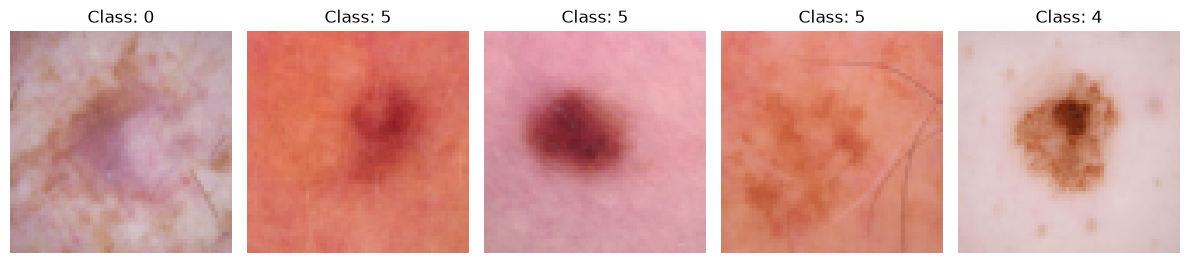

In [21]:
# let's actually look at some images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_dataset[i]
    
    axes[i].imshow(image)
    axes[i].set_title(f"Class: {label[0]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()